# SSHydro Results — Interactive Viewer
**GRwater project**  
Interactive notebook with:
- 📍 Node position widgets (XY + depth offsets) with auto-replot
- 🗓 Datetime range sliders
- 🔲 Panel & series toggles
- 💾 PNG export with custom filename & DPI

---

## 0 · Imports & setup

In [10]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ── ipywidgets ──────────────────────────────────────────────────────────────
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Layout, HTML, Label
from IPython.display import display, clear_output

# Use widget backend (ipympl) for interactive figures; fall back to inline
try:
    %matplotlib widget
except Exception:
    %matplotlib inline

# ── project-specific ────────────────────────────────────────────────────────
module_path = Path('../../GRwater_geophy').resolve()
if str(module_path) not in sys.path:
    sys.path.append(str(module_path))
import Agramon_utils as AgUtils

from pyCATHY import cathy_tools, cathy_utils
from pyCATHY.importers import cathy_inputs as in_CT
from pyCATHY.importers import cathy_outputs as out_CT
from pyCATHY.plotters import cathy_plots as cplt

print('✓ All imports OK')

✓ All imports OK


## 1 · Configuration — choose your scenario

In [11]:
rootPath = Path('..').resolve()
path2prj = Path('../SSHydro/').resolve()
log_file = Path('simulation_log.csv')

df_log = pd.read_csv(log_file)
print('Available simulations:')
display(df_log)

Available simulations:


,sim_index,datetime,start_year,end_year,ZROOT,PMIN
0,1,2026-03-19 10:08:24,2011,2012,1.0,-5


In [12]:
scenario_widget = widgets.Dropdown(
    options=list(df_log['sim_index'].astype(int)),
    value=int(df_log['sim_index'].iloc[0]),
    description='Scenario:',
    style={'description_width': 'initial'},
    layout=Layout(width='250px')
)
display(scenario_widget)

Dropdown(description='Scenario:', layout=Layout(width='250px'), options=(1,), style=DescriptionStyle(descripti…

## 2 · Load data for selected scenario

In [13]:
scenario = scenario_widget.value
row = df_log[df_log['sim_index'] == scenario].iloc[0]

# ── ERA5 ────────────────────────────────────────────────────────────────────
ds = AgUtils.load_era5_series(
    root_path=rootPath,
    start_year=int(row['start_year']),
    end_year=int(row['end_year']),
)
gdf_Agramon = AgUtils.load_plot_shapefiles(module_path / 'shapefiles')
daily_ts    = AgUtils.extract_point_timeseries(ds, gdf_Agramon)

pev_series = daily_ts['pev'].to_series()
tp_series  = daily_ts['tp'].to_series()

# ── CATHY project ───────────────────────────────────────────────────────────
prj_name = [p for p in path2prj.iterdir()
            if p.is_dir() and f'_sim{scenario}' in p.name][0]
simu = cathy_tools.CATHY(dirName=path2prj, prj_name=prj_name)

# ── CATHY outputs ────────────────────────────────────────────────────────────
df_psi      = simu.read_outputs('psi')
df_sw, _    = simu.read_outputs('sw')
df_ET       = simu.read_outputs('ET')

start_date  = pd.to_datetime(daily_ts['tp'].valid_time[0].values)
df_dates    = cathy_utils.change_x2date(df_psi.index, start_date)
df_dates_sw = cathy_utils.change_x2date(df_sw.index,  start_date)

# ── ET spatial mean ──────────────────────────────────────────────────────────
ET_xr      = df_ET.set_index(['X','Y','time']).to_xarray()
ET_xr      = ET_xr.rio.set_spatial_dims('X','Y')
ET_xr_mean = ET_xr.mean(dim=['X','Y']) * (1e3 * 86400)   # → mm/day
time_dates = start_date + ET_xr['time'].values

# ── Colour palette ───────────────────────────────────────────────────────────
COLORS = {
    'uphill_surface':   '#0072B2',
    'uphill_1m':        '#56B4E9',
    'downhill_surface': '#D55E00',
    'downhill_1m':      '#E69F00',
    'ET_mean':          '#009E73',
}

print(f'✓ Loaded scenario {scenario}: {prj_name.name}')
print(f'  Date range: {df_dates.min().date()} → {df_dates.max().date()}')

Centroid lon, lat: -1.6721825320383024, 38.43936596827434
Nearest grid point lat, lon: 38.44, -1.69225


/home/z0272571a@campus.csic.es/Nextcloud/BenCSIC/Codes/Tech4agro_org/GRwater_geophy/Agramon_utils.py:999: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf_proj.geometry.centroid.iloc[0]


🏁 Initiate CATHY object

✓ Loaded scenario 1: sc_2011-2012_rd1.0_pmin-5.0_sim1
  Date range: 2011-01-01 → 2011-02-14


## 3 · 📍 Node position selector

Edit the **XY coordinates** or **depth offsets** for the uphill and downhill reference points.  
All plots refresh automatically on every change.  
Node indices and resolved 3-D positions are shown in the green status box.

> **Tip:** Check mesh bounds in the 3-D viewer (Section 4) to pick meaningful XY values.

In [21]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  Shared mutable node state — all plots read from here                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
NODE_STATE = {}
_plot_refresh_callbacks = []   # populated by sections 5 & 6

def recompute_nodes(uh_x, uh_y, dh_x, dh_y,
                    depth_surf, depth_1m, depth_2m):
    """
    Resolve all node ids + positions via simu.find_nearest_node and
    store them in NODE_STATE.  Returns an HTML summary string.
    """
    # uphill 2-D surface elevation
    _, uh_2d_pos = simu.find_nearest_node([uh_x, uh_y])
    z_uh = float(uh_2d_pos[0][2])

    uh_surf_node, uh_surf_pos = simu.find_nearest_node([uh_x, uh_y, z_uh - depth_surf])
    uh_1m_node,   uh_1m_pos   = simu.find_nearest_node([uh_x, uh_y, z_uh - depth_1m])
    uh_2m_node,   uh_2m_pos   = simu.find_nearest_node([uh_x, uh_y, z_uh - depth_2m])

    # downhill 2-D surface elevation
    _, dh_2d_pos = simu.find_nearest_node([dh_x, dh_y])
    z_dh = float(dh_2d_pos[0][2])

    dh_surf_node, dh_surf_pos = simu.find_nearest_node([dh_x, dh_y, z_dh - depth_surf])
    dh_1m_node,   dh_1m_pos   = simu.find_nearest_node([dh_x, dh_y, z_dh - depth_1m])

    NODE_STATE.update(dict(
        uphill_surface_node   = uh_surf_node,
        uphill_surface_pos    = uh_surf_pos,
        uphill_1m_node        = uh_1m_node,
        uphill_1m_pos         = uh_1m_pos,
        uphill_2m_node        = uh_2m_node,
        uphill_2m_pos         = uh_2m_pos,
        downhill_surface_node = dh_surf_node,
        downhill_surface_pos  = dh_surf_pos,
        downhill_1m_node      = dh_1m_node,
        downhill_1m_pos       = dh_1m_pos,
        # store widget values for use in plot titles
        uh_x=uh_x, uh_y=uh_y, dh_x=dh_x, dh_y=dh_y,
        depth_surf=depth_surf, depth_1m=depth_1m, depth_2m=depth_2m,
    ))

    def _fmt(pos):
        return str(tuple(round(float(v), 2) for v in pos[0]))

    return (
        f'<b>⬆ Uphill</b>  X={uh_x}, Y={uh_y}  — surface z = {z_uh:.2f} m<br>'
        f'&emsp;• surf node <b>{uh_surf_node}</b> @ {_fmt(uh_surf_pos)}<br>'
        f'&emsp;• −{depth_1m} m node <b>{uh_1m_node}</b> @ {_fmt(uh_1m_pos)}<br>'
        f'&emsp;• −{depth_2m} m node <b>{uh_2m_node}</b> @ {_fmt(uh_2m_pos)}<br>'
        f'<b>⬇ Downhill</b>  X={dh_x}, Y={dh_y}  — surface z = {z_dh:.2f} m<br>'
        f'&emsp;• surf node <b>{dh_surf_node}</b> @ {_fmt(dh_surf_pos)}<br>'
        f'&emsp;• −{depth_1m} m node <b>{dh_1m_node}</b> @ {_fmt(dh_1m_pos)}'
    )


# ── Widget definitions ────────────────────────────────────────────────────────
_fw = Layout(width='140px')
_ls = {'description_width': '30px'}

# XY coordinates
w_uh_x = widgets.FloatText(value=250., description='X:', style=_ls, layout=_fw)
w_uh_y = widgets.FloatText(value=100., description='Y:', style=_ls, layout=_fw)
w_dh_x = widgets.FloatText(value=25.,  description='X:', style=_ls, layout=_fw)
w_dh_y = widgets.FloatText(value=50.,  description='Y:', style=_ls, layout=_fw)

# Depth offsets
_ds = {'description_width': '80px'}
w_depth_surf = widgets.BoundedFloatText(
    value=0.2, min=0.0, max=50., step=0.05,
    description='surf depth:', style=_ds, layout=Layout(width='180px'),
    tooltip='Offset below surface for the near-surface node (m)'
)
w_depth_1m = widgets.BoundedFloatText(
    value=1.0, min=0.05, max=50., step=0.1,
    description='−1 m depth:', style=_ds, layout=Layout(width='180px'),
    tooltip='Second depth offset (m)'
)
w_depth_2m = widgets.BoundedFloatText(
    value=2.0, min=0.1, max=50., step=0.1,
    description='−2 m depth:', style=_ds, layout=Layout(width='180px'),
    tooltip='Third depth offset — used for uphill only (m)'
)

# Status output
node_status_html = HTML(value='<i>Initialising…</i>')

# ── Auto-refresh on any change ────────────────────────────────────────────────
def _run_node_recompute(_=None):
    """Recompute nodes then propagate to every registered plot refresh."""
    try:
        summary = recompute_nodes(
            w_uh_x.value, w_uh_y.value,
            w_dh_x.value, w_dh_y.value,
            w_depth_surf.value, w_depth_1m.value, w_depth_2m.value
        )
        node_status_html.value = (
            '<div style="background:#f0fff0;border:1px solid #7dbb7d;'
            'border-radius:5px;padding:7px 10px;'
            'font-family:monospace;font-size:12px;line-height:1.6;">'
            + summary + '</div>'
        )
    except Exception as exc:
        node_status_html.value = (
            f'<div style="background:#fff0f0;border:1px solid #e07070;'
            f'border-radius:5px;padding:6px;">'
            f'<b>❌ Node lookup failed:</b> {exc}</div>'
        )
        return
    for fn in _plot_refresh_callbacks:
        fn()

for _w in [w_uh_x, w_uh_y, w_dh_x, w_dh_y,
           w_depth_surf, w_depth_1m, w_depth_2m]:
    _w.observe(_run_node_recompute, names='value')

# ── Layout ────────────────────────────────────────────────────────────────────
uphill_box = VBox([
    HTML('<b style="color:#0072B2">⬆ Uphill point</b>'),
    HBox([w_uh_x, w_uh_y])
], layout=Layout(border='1px solid #aad4f5', padding='8px 12px',
                  margin='4px', border_radius='6px'))

downhill_box = VBox([
    HTML('<b style="color:#D55E00">⬇ Downhill point</b>'),
    HBox([w_dh_x, w_dh_y])
], layout=Layout(border='1px solid #f5c89a', padding='8px 12px',
                  margin='4px', border_radius='6px'))

depth_box = VBox([
    HTML('<b style="color:#555">Depth offsets (both points)</b>'),
    w_depth_surf, w_depth_1m, w_depth_2m
], layout=Layout(border='1px solid #d7bde2', padding='8px 12px',
                  margin='4px', border_radius='6px'))

node_panel = VBox([
    HTML('<h4 style="margin:2px 0 8px 0">📍 Node Position Controls</h4>'),
    HBox([uphill_box, downhill_box, depth_box]),
    HTML('<b>Resolved nodes:</b>'),
    node_status_html,
], layout=Layout(border='2px solid #b0c4de', padding='12px',
                  margin='8px 0', border_radius='8px',
                  background='#fafcff'))

display(node_panel)

# Initialise NODE_STATE with defaults (plots not yet registered, that's fine)
_run_node_recompute()
print('✓ NODE_STATE initialised')

✓ NODE_STATE initialised


## 4 · 3-D mesh viewer (PyVista)
Selected nodes shown as red points. Re-run this cell after changing node positions to update the 3-D view.

/tmp/ipykernel_34403/2779696408.py:14: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


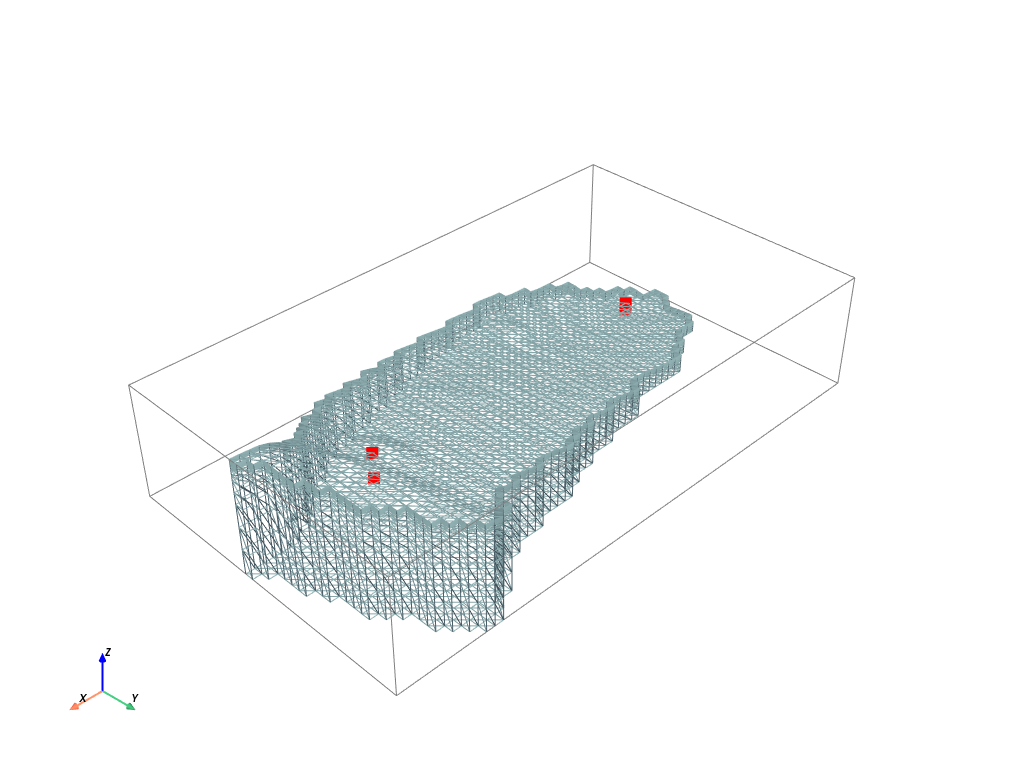

In [23]:
import pyvista as pv

vtk_path = os.path.join(simu.workdir, simu.project_name, 'vtk', prj_name.name + '.vtk')
pl   = pv.Plotter(notebook=True)
mesh = pv.read(vtk_path)
pl.add_mesh(mesh, style='wireframe')
pl.add_bounding_box()
pl.add_axes()

for key in ['uphill_surface_pos', 'uphill_1m_pos',
            'downhill_surface_pos', 'downhill_1m_pos']:
    pl.add_points(NODE_STATE[key][0], color='red', point_size=12)

pl.show()

## 5 · Interactive time-series viewer — Rain / ETp / ψ / sw

All panels **auto-update** when node positions or depths are changed above.  
Legend labels show the resolved node index.

In [25]:
# ── Plot function ─────────────────────────────────────────────────────────────
def plot_hydro(date_start, date_end, show_rain, show_psi, show_sw,
               show_uphill_surf, show_uphill_1m,
               show_downhill_surf, show_downhill_1m):

    d0, d1 = pd.Timestamp(date_start), pd.Timestamp(date_end)
    pev_mask = (pev_series.index >= d0) & (pev_series.index <= d1)
    psi_mask = (df_dates    >= d0) & (df_dates    <= d1)
    sw_mask  = (df_dates_sw >= d0) & (df_dates_sw <= d1)

    # Pull current node ids from shared state
    uh_s = NODE_STATE['uphill_surface_node']
    uh_1 = NODE_STATE['uphill_1m_node']
    dh_s = NODE_STATE['downhill_surface_node']
    dh_1 = NODE_STATE['downhill_1m_node']
    d1m  = NODE_STATE['depth_1m']

    height_ratios = [r for r, f in zip([1,2,2], [show_rain,show_psi,show_sw]) if f]
    n_panels = len(height_ratios) or 1
    if not height_ratios:
        height_ratios = [1]

    fig, raw_axes = plt.subplots(
        n_panels, 1, figsize=(14, 3*n_panels+1),
        sharex=True, gridspec_kw={'height_ratios': height_ratios}
    )
    if n_panels == 1:
        raw_axes = [raw_axes]
    ax_iter = iter(raw_axes)

    if show_rain:
        ax = next(ax_iter)
        ax.bar(pev_series[pev_mask].index, pev_series[pev_mask].values,
               width=1.0, color='grey', label='ETp', alpha=0.5)
        ax.bar(pev_series[pev_mask].index, tp_series[pev_mask].values,
               width=1.0, color='skyblue', label='Rain')
        ax.invert_yaxis()
        ax.set_ylabel('mm/day')
        ax.set_title('Precipitation & Potential ET', fontsize=10, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)

    if show_psi:
        ax = next(ax_iter)
        if show_uphill_surf:
            ax.plot(df_dates[psi_mask], df_psi.loc[psi_mask, uh_s].values,
                    label=f'Uphill surf  n={uh_s}', color=COLORS['uphill_surface'],
                    marker='+', linestyle='-')
        if show_uphill_1m:
            ax.plot(df_dates[psi_mask], df_psi.loc[psi_mask, uh_1].values,
                    label=f'Uphill −{d1m} m  n={uh_1}',
                    color=COLORS['uphill_1m'], linestyle='--')
        if show_downhill_surf:
            ax.plot(df_dates[psi_mask], df_psi.loc[psi_mask, dh_s].values,
                    label=f'Downhill surf  n={dh_s}', color=COLORS['downhill_surface'],
                    marker='o', linestyle='-', markersize=3)
        if show_downhill_1m:
            ax.plot(df_dates[psi_mask], df_psi.loc[psi_mask, dh_1].values,
                    label=f'Downhill −{d1m} m  n={dh_1}',
                    color=COLORS['downhill_1m'], linestyle='--')
        ax.set_ylabel('ψ (m)')
        ax.set_title('Pressure Head', fontsize=10, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)

    if show_sw:
        ax = next(ax_iter)
        if show_uphill_surf:
            ax.plot(df_dates_sw[sw_mask], df_sw.loc[sw_mask, uh_s].values,
                    label=f'Uphill surf  n={uh_s}', color=COLORS['uphill_surface'],
                    marker='+', linestyle='-')
        if show_uphill_1m:
            ax.plot(df_dates_sw[sw_mask], df_sw.loc[sw_mask, uh_1].values,
                    label=f'Uphill −{d1m} m  n={uh_1}',
                    color=COLORS['uphill_1m'], linestyle='--')
        if show_downhill_surf:
            ax.plot(df_dates_sw[sw_mask], df_sw.loc[sw_mask, dh_s].values,
                    label=f'Downhill surf  n={dh_s}', color=COLORS['downhill_surface'],
                    marker='o', linestyle='-', markersize=3)
        if show_downhill_1m:
            ax.plot(df_dates_sw[sw_mask], df_sw.loc[sw_mask, dh_1].values,
                    label=f'Downhill −{d1m} m  n={dh_1}',
                    color=COLORS['downhill_1m'], linestyle='--')
        ax.set_ylabel('sw (−)')
        ax.set_xlabel('Date')
        ax.set_title('Soil Water Content', fontsize=10, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)

    locator   = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    for a in raw_axes:
        a.xaxis.set_major_locator(locator)
        a.xaxis.set_major_formatter(formatter)
    fig.autofmt_xdate()
    uh_xy = (NODE_STATE['uh_x'], NODE_STATE['uh_y'])
    dh_xy = (NODE_STATE['dh_x'], NODE_STATE['dh_y'])
    fig.suptitle(
        f'Sc.{scenario}  |  Uphill {uh_xy}  Downhill {dh_xy}  |  {d0.date()} → {d1.date()}',
        fontsize=10, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    return fig


# ── Widgets ──────────────────────────────────────────────────────────────────
date_min   = df_dates.min().to_pydatetime()
date_max   = df_dates.max().to_pydatetime()
_date_opts = pd.date_range(date_min, date_max, freq='D').to_pydatetime().tolist()

date_range_slider = widgets.SelectionRangeSlider(
    options=_date_opts, index=(0, len(_date_opts)-1),
    description='Date range', style={'description_width': 'initial'},
    layout=Layout(width='80%')
)
toggle_rain = widgets.ToggleButton(value=True, description='Rain / ETp',
                                   button_style='info', layout=Layout(width='110px'))
toggle_psi  = widgets.ToggleButton(value=True, description='ψ (psi)',
                                   button_style='info', layout=Layout(width='110px'))
toggle_sw   = widgets.ToggleButton(value=True, description='sw',
                                   button_style='info', layout=Layout(width='110px'))

cb_uphill_surf   = widgets.Checkbox(value=True, description='Uphill surface',  indent=False)
cb_uphill_1m     = widgets.Checkbox(value=True, description='Uphill −1 m',     indent=False)
cb_downhill_surf = widgets.Checkbox(value=True, description='Downhill surface', indent=False)
cb_downhill_1m   = widgets.Checkbox(value=True, description='Downhill −1 m',    indent=False)

export_filename = widgets.Text(value='hydro_timeseries.png', description='Filename:',
                               style={'description_width': 'initial'}, layout=Layout(width='280px'))
export_dpi    = widgets.BoundedIntText(value=150, min=72, max=600, step=1,
                                        description='DPI:', layout=Layout(width='130px'))
export_btn    = widgets.Button(description='💾  Export PNG',
                               button_style='success', layout=Layout(width='140px'))
export_status = widgets.HTML(value='')
fig_out       = widgets.Output()
_current_fig  = [None]

def hydro_refresh(_=None):
    if not NODE_STATE:
        return
    d0, d1 = date_range_slider.value
    with fig_out:
        clear_output(wait=True)
        fig = plot_hydro(
            d0, d1,
            toggle_rain.value, toggle_psi.value, toggle_sw.value,
            cb_uphill_surf.value, cb_uphill_1m.value,
            cb_downhill_surf.value, cb_downhill_1m.value
        )
        _current_fig[0] = fig
        plt.show()

def on_export(b):
    if _current_fig[0] is None:
        export_status.value = '<span style="color:red">No figure yet.</span>'
        return
    fname = export_filename.value.strip() or 'hydro_timeseries.png'
    if not fname.lower().endswith('.png'): fname += '.png'
    _current_fig[0].savefig(fname, dpi=export_dpi.value, bbox_inches='tight')
    export_status.value = f'<span style="color:green">✓ Saved → <b>{fname}</b></span>'

for w in [date_range_slider, toggle_rain, toggle_psi, toggle_sw,
          cb_uphill_surf, cb_uphill_1m, cb_downhill_surf, cb_downhill_1m]:
    w.observe(hydro_refresh, names='value')
export_btn.on_click(on_export)

# Register so node edits auto-refresh this section too
_plot_refresh_callbacks.append(hydro_refresh)

panel_row  = HBox([Label('Panels:'), toggle_rain, toggle_psi, toggle_sw])
node_row   = HBox([Label('Series:'), cb_uphill_surf, cb_uphill_1m,
                   cb_downhill_surf, cb_downhill_1m])
export_row = HBox([export_btn, export_filename, export_dpi, export_status],
                  layout=Layout(align_items='center'))
controls   = VBox([
    HTML('<b>🗓  Date range</b>'),
    date_range_slider, panel_row, node_row, export_row,
], layout=Layout(border='1px solid #ccc', padding='10px', margin='4px 0'))

display(controls, fig_out)
hydro_refresh()

Output()

## 6 · Interactive ET viewer — sw + Actual ETa

Auto-updates on node position changes.

In [ ]:
def plot_ET(date_start, date_end,
            show_uphill_surf, show_uphill_1m,
            show_downhill_surf, show_downhill_1m):

    d0, d1 = pd.Timestamp(date_start), pd.Timestamp(date_end)
    sw_mask = (df_dates_sw >= d0) & (df_dates_sw <= d1)
    et_mask = (time_dates  >= d0) & (time_dates  <= d1)

    uh_s = NODE_STATE['uphill_surface_node']
    uh_1 = NODE_STATE['uphill_1m_node']
    dh_s = NODE_STATE['downhill_surface_node']
    dh_1 = NODE_STATE['downhill_1m_node']
    d1m  = NODE_STATE['depth_1m']

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    ax0, ax1  = axes

    if show_uphill_surf:
        ax0.plot(df_dates_sw[sw_mask], df_sw.loc[sw_mask, uh_s].values,
                 label=f'Uphill surf  n={uh_s}', color=COLORS['uphill_surface'],
                 marker='+', linestyle='-')
    if show_uphill_1m:
        ax0.plot(df_dates_sw[sw_mask], df_sw.loc[sw_mask, uh_1].values,
                 label=f'Uphill −{d1m} m  n={uh_1}',
                 color=COLORS['uphill_1m'], linestyle='--')
    if show_downhill_surf:
        ax0.plot(df_dates_sw[sw_mask], df_sw.loc[sw_mask, dh_s].values,
                 label=f'Downhill surf  n={dh_s}', color=COLORS['downhill_surface'],
                 marker='o', linestyle='-', markersize=3)
    if show_downhill_1m:
        ax0.plot(df_dates_sw[sw_mask], df_sw.loc[sw_mask, dh_1].values,
                 label=f'Downhill −{d1m} m  n={dh_1}',
                 color=COLORS['downhill_1m'], linestyle='--')
    ax0.set_ylabel('sw (−)')
    ax0.set_title('Soil Water Content', fontsize=10, fontweight='bold')
    ax0.legend(loc='upper right', fontsize=8)
    ax0.grid(True, linestyle='--', alpha=0.4)

    ax1.scatter(time_dates[et_mask],
                ET_xr_mean['ACT. ETRA'].values[et_mask],
                c=COLORS['ET_mean'], s=14, label='ETa mean')
    ax1.set_ylabel('ETa (mm/day)')
    ax1.set_xlabel('Date')
    ax1.set_title('Actual Evapotranspiration (spatial mean)', fontsize=10, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.4)

    locator   = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    for ax in axes:
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
    fig.autofmt_xdate()
    fig.suptitle(
        f'Sc.{scenario}  |  sw & ETa  |  {d0.date()} → {d1.date()}',
        fontsize=10, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    return fig


et_date_range = widgets.SelectionRangeSlider(
    options=_date_opts, index=(0, len(_date_opts)-1),
    description='Date range', style={'description_width': 'initial'},
    layout=Layout(width='80%')
)
et_cb_uphill_surf   = widgets.Checkbox(value=True, description='Uphill surface',  indent=False)
et_cb_uphill_1m     = widgets.Checkbox(value=True, description='Uphill −1 m',     indent=False)
et_cb_downhill_surf = widgets.Checkbox(value=True, description='Downhill surface', indent=False)
et_cb_downhill_1m   = widgets.Checkbox(value=True, description='Downhill −1 m',    indent=False)

et_export_filename = widgets.Text(value='et_timeseries.png', description='Filename:',
                                   style={'description_width': 'initial'}, layout=Layout(width='260px'))
et_export_dpi    = widgets.BoundedIntText(value=150, min=72, max=600, step=1,
                                           description='DPI:', layout=Layout(width='130px'))
et_export_btn    = widgets.Button(description='💾  Export PNG',
                                  button_style='success', layout=Layout(width='140px'))
et_export_status = widgets.HTML(value='')
et_fig_out       = widgets.Output()
_et_current_fig  = [None]

def et_refresh(_=None):
    if not NODE_STATE:
        return
    d0, d1 = et_date_range.value
    with et_fig_out:
        clear_output(wait=True)
        fig = plot_ET(
            d0, d1,
            et_cb_uphill_surf.value, et_cb_uphill_1m.value,
            et_cb_downhill_surf.value, et_cb_downhill_1m.value
        )
        _et_current_fig[0] = fig
        plt.show()

def on_et_export(b):
    if _et_current_fig[0] is None:
        et_export_status.value = '<span style="color:red">No figure yet.</span>'
        return
    fname = et_export_filename.value.strip() or 'et_timeseries.png'
    if not fname.lower().endswith('.png'): fname += '.png'
    _et_current_fig[0].savefig(fname, dpi=et_export_dpi.value, bbox_inches='tight')
    et_export_status.value = f'<span style="color:green">✓ Saved → <b>{fname}</b></span>'

for w in [et_date_range, et_cb_uphill_surf, et_cb_uphill_1m,
          et_cb_downhill_surf, et_cb_downhill_1m]:
    w.observe(et_refresh, names='value')
et_export_btn.on_click(on_et_export)

_plot_refresh_callbacks.append(et_refresh)   # register for node auto-refresh

et_node_row   = HBox([Label('Series:'), et_cb_uphill_surf, et_cb_uphill_1m,
                      et_cb_downhill_surf, et_cb_downhill_1m])
et_export_row = HBox([et_export_btn, et_export_filename, et_export_dpi, et_export_status],
                     layout=Layout(align_items='center'))
et_controls   = VBox([
    HTML('<b>🗓  Date range</b>'),
    et_date_range, et_node_row, et_export_row,
], layout=Layout(border='1px solid #ccc', padding='10px', margin='4px 0'))

display(et_controls, et_fig_out)
et_refresh()

## 7 · ERA5 forcing preview

In [ ]:
_era5_opts = pd.date_range(pev_series.index.min(), pev_series.index.max(),
                            freq='D').to_pydatetime().tolist()
era5_date_range = widgets.SelectionRangeSlider(
    options=_era5_opts, index=(0, len(_era5_opts)-1),
    description='Date range', style={'description_width': 'initial'},
    layout=Layout(width='80%')
)
era5_export_btn    = widgets.Button(description='💾  Export PNG',
                                    button_style='success', layout=Layout(width='140px'))
era5_export_status = widgets.HTML(value='')
era5_export_fname  = widgets.Text(value='era5_forcing.png', description='Filename:',
                                   style={'description_width': 'initial'}, layout=Layout(width='240px'))
era5_fig_out = widgets.Output()
_era5_fig    = [None]

def plot_era5(date_start, date_end):
    d0, d1 = pd.Timestamp(date_start), pd.Timestamp(date_end)
    mask = (pev_series.index >= d0) & (pev_series.index <= d1)
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.bar(pev_series[mask].index, pev_series[mask].values,
           width=1.0, color='grey', label='ETp', alpha=0.5)
    ax.bar(tp_series[mask].index, tp_series[mask].values,
           width=1.0, color='skyblue', label='Rain')
    ax.invert_yaxis()
    ax.set_ylabel('mm/day')
    ax.set_title(f'ERA5 Forcing  |  {d0.date()} → {d1.date()}', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
    locator, formatter = mdates.AutoDateLocator(), mdates.ConciseDateFormatter(mdates.AutoDateLocator())
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    fig.autofmt_xdate()
    plt.tight_layout()
    return fig

def era5_refresh(_=None):
    d0, d1 = era5_date_range.value
    with era5_fig_out:
        clear_output(wait=True)
        fig = plot_era5(d0, d1)
        _era5_fig[0] = fig
        plt.show()

def on_era5_export(b):
    if _era5_fig[0] is None:
        era5_export_status.value = '<span style="color:red">No figure yet.</span>'
        return
    fname = era5_export_fname.value.strip() or 'era5_forcing.png'
    if not fname.lower().endswith('.png'): fname += '.png'
    _era5_fig[0].savefig(fname, dpi=150, bbox_inches='tight')
    era5_export_status.value = f'<span style="color:green">✓ Saved → <b>{fname}</b></span>'

era5_date_range.observe(era5_refresh, names='value')
era5_export_btn.on_click(on_era5_export)

era5_export_row = HBox([era5_export_btn, era5_export_fname, era5_export_status],
                       layout=Layout(align_items='center'))
era5_controls   = VBox([
    HTML('<b>🗓  Date range</b>'),
    era5_date_range, era5_export_row,
], layout=Layout(border='1px solid #ccc', padding='10px', margin='4px 0'))

display(era5_controls, era5_fig_out)
era5_refresh()